# 🫀Heart Disease Prediction
## Data Preprocessing
In this notebook, the dataset is prepared for machine learning by handling invalid values, encoding categorical variables, splitting the data into training and testing sets, and applying feature scaling where necessary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
# project path
project_root = Path.cwd().parent
data_dir = project_root / "data"
raw_data_dir = data_dir / "raw"
data_file = raw_data_dir / "heart.csv"

In [3]:
# Load data
df = pd.read_csv(data_file)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Separate X and y
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

In [5]:
# Train & test split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

## 1. Handle Invalid Values

In [6]:
# Preprocessing inside Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class ZeroToNaNTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].replace(0, np.nan)
        return X


### pipeline

In [7]:
numeric_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG",
                        "ExerciseAngina", "ST_Slope"]

numeric_transformer = Pipeline(steps=[("zero_to_nan", ZeroToNaNTransformer(columns=["RestingBP", "Cholesterol"])),
                                      ("imputer", SimpleImputer(strategy="median")),
                                      ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("onehot", OneHotEncoder(handle_unknown="ignore"))])
# 
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),
                                               ("cat", categorical_transformer, categorical_features)])


In [8]:
# # replace zeros to nan
# df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
# df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

In [9]:
# # Replace nan with median
# df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())
# df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())

In [10]:
# # chek..
# invalid_values = {
#     "RestingBP == 0" : (df["RestingBP"]==0).sum(),
#     "Cholesterol == 0" : (df["Cholesterol"]==0).sum(),
#      "Missing RestingBP": df["RestingBP"].isna().sum(),
#     "Missing Cholesterol": df["Cholesterol"].isna().sum()
# }

# invalid_values

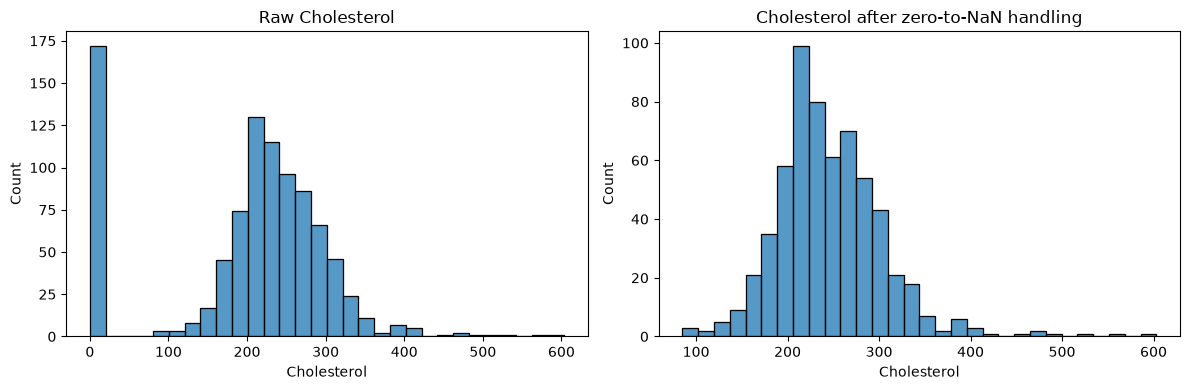

In [11]:
# Cholesterol before & after zero-to-NaN handling
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Cholesterol"], bins=30, ax=ax[0])
ax[0].set_title("Raw Cholesterol")

sns.histplot(X_train["Cholesterol"].replace(0, np.nan).dropna(), bins=30, ax=ax[1])
ax[1].set_title("Cholesterol after zero-to-NaN handling")

plt.tight_layout()
plt.show()


In [12]:
# save a copy..
df_processed = df.copy()
# just for save
df_processed["RestingBP"] = df_processed["RestingBP"].replace(0, np.nan)
df_processed["Oldpeak"] = df_processed["Oldpeak"].mask(df_processed["Oldpeak"] < 0, np.nan)

df_processed.to_csv("../data/processed/heart_processed.csv", index=False)


## 2. Create Preprocessing Pipeline
## 2.1 Logistic Regression model

In [13]:
print(X.shape)
print(y.shape)


(918, 11)
(918,)


In [14]:
# check result
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(734, 11)
(184, 11)
HeartDisease
1    406
0    328
Name: count, dtype: int64
HeartDisease
1    102
0     82
Name: count, dtype: int64


In [15]:
# # categorical & numeric features
# categorical_features = [
#     "Sex",
#     "ChestPainType",
#     "RestingECG",
#     "ExerciseAngina",
#     "ST_Slope"
# ]

# numerical_features = [
#     "Age",
#     "RestingBP",
#     "Cholesterol",
#     "FastingBS",
#     "MaxHR",
#     "Oldpeak"
# ]

In [16]:
# preprocessor = ColumnTransformer([("categorical",
#                                 OneHotEncoder(handle_unknown="ignore",sparse_output=False),
#                                 categorical_features),
                               
#                                 ("numeric",
#                                  StandardScaler(),
#                                  numerical_features)])

preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [18]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(734, 21)
(184, 21)


In [19]:
# import some tools for build machine learning model & evaluation model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.metrics import ConfusionMatrixDisplay

In [20]:
logistic_pipeline = Pipeline(steps=[
                           ("preprocessor", preprocessor),
                           ("LogisticRegresion", LogisticRegression(random_state=42, max_iter=500))])

In [21]:
# fit model
logistic_pipeline.fit(X_train, y_train)
# model score
logistic_pipeline.score(X_test, y_test)

0.8858695652173914

In [22]:
# prediction..
y_preds = logistic_pipeline.predict(X_test)

evaluation = {
              "model" : "Logistic Regression",
              "accuracy_score" : accuracy_score(y_test, y_preds),
              "prediction_score" : precision_score(y_test, y_preds),
              "recal_score" : recall_score(y_test, y_preds),
              "f1_score" : f1_score(y_test, y_preds)
              }

In [23]:
evaluation

{'model': 'Logistic Regression',
 'accuracy_score': 0.8858695652173914,
 'prediction_score': 0.8857142857142857,
 'recal_score': 0.9117647058823529,
 'f1_score': 0.8985507246376812}

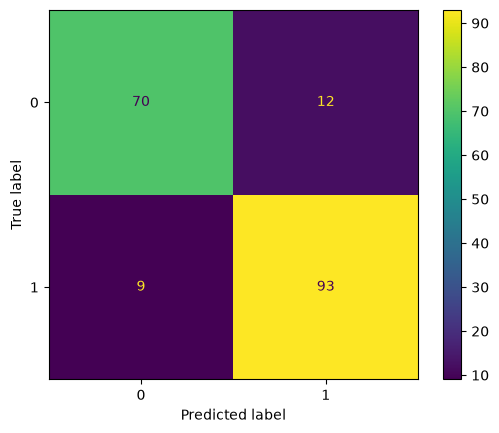

In [24]:
ConfusionMatrixDisplay.from_estimator(logistic_pipeline,
                                      X_test,
                                      y_test)

In [25]:
model_resualt = pd.DataFrame([evaluation.values()],columns=["Model", "Accuracy", "Prediction", "Recall", "F1-Score"])
model_resualt

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.88587,0.885714,0.911765,0.898551


### Logistic Regression Evaluation

- The Logistic Regression model achieved an accuracy of **88.58%** on the test set.
- The model correctly identified **93 patients with heart disease** and **70 healthy individuals**.
- Only **9 patients** were incorrectly classified as healthy (False Negatives), while **12 healthy individuals** were incorrectly classified as having heart disease (False Positives).
- The model achieved a **Recall of 91.17%**, indicating that it successfully detected most patients with heart disease.
- Overall, Logistic Regression provides a strong baseline model for this classification task.

## 2.2 DecisionTreeClassifier

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
# pipeline
decision_tree_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                          ("Classifier", DecisionTreeClassifier(random_state=42))
                                        
]
)

In [28]:
# train model
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

In [29]:
# create a function for evaluation model
def evaluate_modle(model_name, pipeline, X_test, y_test):
    """
    this function evaluating each model whit `accuracy_score`, `prediction_score`, `recal_score`, `f1_score`
    """
    y_preds = pipeline.predict(X_test)
    evaluation = {
              "model" : model_name,
              "accuracy_score" : accuracy_score(y_test, y_preds),
              "prediction_score" : precision_score(y_test, y_preds),
              "recal_score" : recall_score(y_test, y_preds),
              "f1_score" : f1_score(y_test, y_preds)
              }
    return evaluation

In [30]:
resualt = evaluate_modle("DecisionTreeClassifier", decision_tree_pipeline, X_test, y_test)
resualt

{'model': 'DecisionTreeClassifier',
 'accuracy_score': 0.7771739130434783,
 'prediction_score': 0.8210526315789474,
 'recal_score': 0.7647058823529411,
 'f1_score': 0.7918781725888325}

In [31]:
model_resualt.loc[len(model_resualt)] = list(resualt.values())
model_resualt

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551
1,DecisionTreeClassifier,0.777174,0.821053,0.764706,0.791878


## DecisionTreeClassifier Evaluation
The Decision Tree classifier performed significantly worse than Logistic Regression across all evaluation metrics.

This suggests that the default Decision Tree model is likely overfitting the training data and does not generalize well to unseen samples.

## 2.3 Random Forest Classifier Model

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
# pipeline

random_forst_pipeline = Pipeline(steps=[("prepocessor", preprocessor),
                                        ("randomforest", RandomForestClassifier(random_state=42))])

In [34]:
# fit model
random_forst_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prepocessor', ...), ('randomforest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [35]:
random_forest_result = evaluate_modle("Random Forest", random_forst_pipeline, X_test, y_test)
random_forest_result

{'model': 'Random Forest',
 'accuracy_score': 0.8804347826086957,
 'prediction_score': 0.8921568627450981,
 'recal_score': 0.8921568627450981,
 'f1_score': 0.8921568627450981}

In [36]:
model_resualt.loc[len(model_resualt)] = list(random_forest_result.values())

In [37]:
model_resualt.round(4)

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986
1,DecisionTreeClassifier,0.7772,0.8211,0.7647,0.7919
2,Random Forest,0.8804,0.8922,0.8922,0.8922


## 2.4 K-Nearest Neighbors (KNN) 

In [38]:
from sklearn.neighbors import KNeighborsClassifier

In [39]:
# pipline
# random seed
np.random.seed(42)
knn_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                               ("KNN", KNeighborsClassifier())])

In [40]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('KNN', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [41]:
knn_result = evaluate_modle("KNN", knn_pipeline, X_test, y_test)
knn_result

{'model': 'KNN',
 'accuracy_score': 0.8804347826086957,
 'prediction_score': 0.9,
 'recal_score': 0.8823529411764706,
 'f1_score': 0.8910891089108911}

In [42]:
model_resualt.loc[len(model_resualt)] = list(knn_result.values())

In [43]:
model_resualt.round(4)

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986
1,DecisionTreeClassifier,0.7772,0.8211,0.7647,0.7919
2,Random Forest,0.8804,0.8922,0.8922,0.8922
3,KNN,0.8804,0.9000,0.8824,0.8911


## 2.5 Support Vector Machine (SVM)

In [44]:
from sklearn.svm import SVC

In [45]:
# pipeline
svm_pipelien = Pipeline(steps=[("preprocessor", preprocessor),
                               ("svm", SVC(random_state=42))])

In [46]:
svm_pipelien.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [47]:
svm_result = evaluate_modle("SVM", svm_pipelien, X_test, y_test)
svm_result

{'model': 'SVM',
 'accuracy_score': 0.8695652173913043,
 'prediction_score': 0.8679245283018868,
 'recal_score': 0.9019607843137255,
 'f1_score': 0.8846153846153846}

In [48]:
model_resualt.loc[len(model_resualt)] = list(svm_result.values())

In [49]:
model_resualt.round(4)

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.8859,0.8857,0.9118,0.8986
1,DecisionTreeClassifier,0.7772,0.8211,0.7647,0.7919
2,Random Forest,0.8804,0.8922,0.8922,0.8922
3,KNN,0.8804,0.9000,0.8824,0.8911
4,SVM,0.8696,0.8679,0.9020,0.8846


## 2.6 XGboost

In [50]:
from xgboost import XGBClassifier

In [51]:
# pipeline
# random seed
np.random.seed(42)
xgboost_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                   ("XGBoost", XGBClassifier())])

In [52]:
xgboost_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('XGBoost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [53]:
xgboost_resualt = evaluate_modle("XGBClassifier", xgboost_pipeline, X_test, y_test)
xgboost_resualt

{'model': 'XGBClassifier',
 'accuracy_score': 0.8586956521739131,
 'prediction_score': 0.8877551020408163,
 'recal_score': 0.8529411764705882,
 'f1_score': 0.87}

In [54]:
model_resualt.loc[len(model_resualt)] = list(xgboost_resualt.values())

In [55]:
model_resualt

,Model,Accuracy,Prediction,Recall,F1-Score
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551
1,DecisionTreeClassifier,0.777174,0.821053,0.764706,0.791878
2,Random Forest,0.880435,0.892157,0.892157,0.892157
3,KNN,0.880435,0.900000,0.882353,0.891089
4,SVM,0.869565,0.867925,0.901961,0.884615
5,XGBClassifier,0.858696,0.887755,0.852941,0.870000


## Make Cross Validation on `RandomForest`, `LogisticRegression`, `SVM` 

In [56]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [57]:
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

In [58]:
# Top three models
models = {"Logistic Regression" : logistic_pipeline,
           "Random Forest" : random_forst_pipeline,
           "SVM" : svm_pipelien}

In [59]:
#  Calculation Cross Validation
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results.round(4)

,Model,Mean F1,Std
0,Logistic Regression,0.8633,0.0226
1,Random Forest,0.8786,0.0160
2,SVM,0.8730,0.0285


To obtain a more reliable comparison, the top three models were evaluated using 5-Fold Stratified Cross Validation based on the F1-score.

The results show that SVM achieved the highest average F1-score, while Random Forest produced a very similar performance. Logistic Regression showed the lowest standard deviation, indicating the most stable performance across different folds.

Overall, Cross Validation confirms that Random Forest and SVM are the strongest candidates for further hyperparameter tuning.

# Summary

In this notebook, multiple machine learning classification algorithms were trained and evaluated using the same preprocessing pipeline.

The following models were implemented:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- XGBoost

Each model was evaluated using Accuracy, Precision, Recall, and F1-Score on the test set.

To obtain a more reliable comparison, the top-performing models were further evaluated using 5-Fold Stratified Cross Validation.

### Key Findings

- Random Forest achieved the best overall performance on the test dataset.
- SVM achieved the highest average F1-score during cross-validation.
- Logistic Regression provided competitive performance while remaining the most interpretable model.
- Decision Tree showed the weakest performance, indicating overfitting.

The comparison demonstrates that Random Forest and SVM are the strongest candidates for hyperparameter tuning in the next stage of the project.

The next notebook will focus on model optimization, hyperparameter tuning, and selecting the final model for deployment.

In [60]:
# Save the results table
model_resualt.round(4).to_csv("../data/raw/model_comparison.csv", index=False)

In [61]:
# Save the models
import joblib

joblib.dump(logistic_pipeline,
            "../models/logistic_regression.pkl")

joblib.dump(decision_tree_pipeline,
            "../models/decision_tree.pkl")

joblib.dump(random_forst_pipeline,
            "../models/random_forest.pkl")

joblib.dump(knn_pipeline,
            "../models/knn.pkl")

joblib.dump(svm_pipelien,
            "../models/svm.pkl")

joblib.dump(xgboost_pipeline,
            "../models/xgboost.pkl")

['../models/xgboost.pkl']

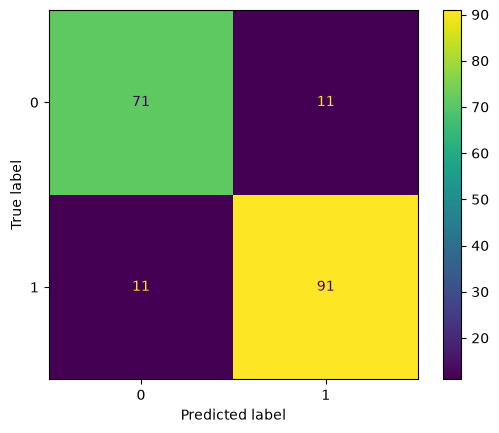

In [62]:
ConfusionMatrixDisplay.from_estimator(random_forst_pipeline,
                                      X_test,
                                      y_test)